# 30-seed campaign progress

Live view of the fixed-design multi-seed campaign in `results_v2/results_files/`
(one `.npz` per completed *(problem, budget, model, seed)* cell, `_fd01` tag).
**Re-run the cell below to refresh.** The dashed line is the target: 30 seeds per bar.
The campaign itself runs in the tmux session `griewank` (`tmux attach -t griewank`).

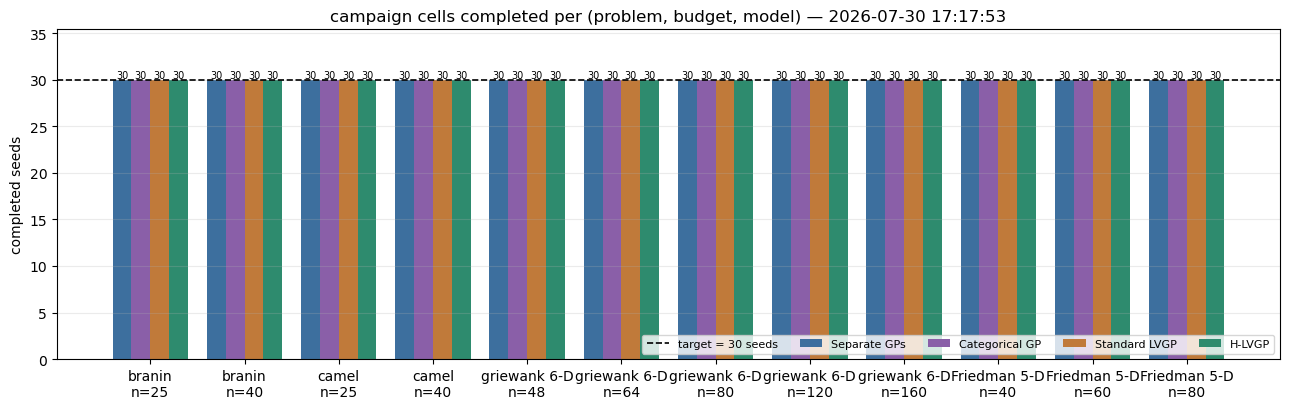

total: 1440/1440 cells (100.0%)


In [117]:
import os, glob, time
import numpy as np, matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "results_v2", "results_files"))
CONFIGS = [("branin_hetero", "branin", [25, 40]),
           ("sixhump_camel", "camel", [25, 40]),
           ("griewank_6d", "griewank 6-D", [48, 64, 80, 120, 160]),
           ("friedman_5d", "Friedman 5-D", [40, 60, 80])]
MODELS = ["separate_gp", "categorical_kernel", "standard_LVGP", "heter_LVGP"]
LABELS = {"separate_gp": "Separate GPs", "categorical_kernel": "Categorical GP",
          "standard_LVGP": "Standard LVGP", "heter_LVGP": "H-LVGP"}
COLORS = {"separate_gp": "#3d6f9e", "categorical_kernel": "#8a5fa8",
          "standard_LVGP": "#c07a3a", "heter_LVGP": "#2e8b6e"}
TARGET = 30

groups, counts = [], {m: [] for m in MODELS}
for prob, disp, budgets in CONFIGS:
    for n in budgets:
        groups.append(f"{disp}\nn={n}")
        for m in MODELS:
            pat = os.path.join(ROOT, prob, m, f"n{n:03d}", f"{m}_seed*_nrep10_n{n:03d}_fd01.npz")
            counts[m].append(len(glob.glob(pat)))

x = np.arange(len(groups)); w = 0.2
fig, ax = plt.subplots(figsize=(13, 4.2))
for i, m in enumerate(MODELS):
    bars = ax.bar(x + (i - 1.5) * w, counts[m], w, color=COLORS[m], label=LABELS[m])
    for b, c in zip(bars, counts[m]):
        ax.annotate(str(c), (b.get_x() + b.get_width()/2, c), ha="center",
                    va="bottom", fontsize=7)
ax.axhline(TARGET, color="k", ls="--", lw=1.2, label=f"target = {TARGET} seeds")
ax.set(xticks=x, xticklabels=groups, ylabel="completed seeds",
       ylim=(0, TARGET * 1.18),
       title=f"campaign cells completed per (problem, budget, model) — {time.strftime('%Y-%m-%d %H:%M:%S')}")
ax.legend(fontsize=8, ncol=5, loc="lower right"); ax.grid(axis="y", alpha=.25)
plt.tight_layout(); plt.show()
 
done = sum(sum(v) for v in counts.values()); total = sum(len(b) for _, _, b in CONFIGS) * len(MODELS) * TARGET
print(f"total: {done}/{total} cells ({100*done/total:.1f}%)")